# 260318 ML Reboot

이 노트북은 `ST-464`, `ST-479`, `ST-481` 3개 스테이션을 대상으로,
`lag 없이`, `누수 없이`, `공선성을 과하게 만들지 않는` 조건으로 다시 설계한 분석 노트입니다.

핵심 전략은 다음과 같습니다.

1. `잔여 대수`를 직접 회귀하지 않습니다.
2. 대신 시간대별 `유입(inflow)`과 `유출(outflow)`을 외생 변수만으로 예측합니다.
3. 예측된 유입/유출을 이용해 스테이션별 재고를 시뮬레이션합니다.

이 방식이 현재 조건에서 가장 안전한 이유는 다음과 같습니다.

- 재고는 본질적으로 누적 상태 변수라서, lag 없이 직접 맞추면 불안정합니다.
- 반면 유입/유출은 `시간`, `요일`, `계절`, `날씨`, `스테이션 고정 정보` 같은 외생 변수로 예측할 수 있습니다.
- 이후 재고는 `초기 재고 + 누적 유입 - 누적 유출`로 계산하므로 구조적으로 해석이 쉽습니다.


## 원칙

### 1. 누수 방지
- 입력 변수에는 미래에만 알 수 있는 값을 넣지 않습니다.
- `전체_이용_분`, `전체_이용_거리`는 개별 이용이 끝난 뒤 확정되는 값이므로 모델 입력에서 제외합니다.
- `실제 유입/유출`, `실제 잔여 대수`, `동시간대 결과 변수`도 입력에 넣지 않습니다.

### 2. 공선성 완화
- `불쾌지수`는 `온도 + 습도`의 파생에 가까워 제외합니다.
- `대여소_ID`와 `위경도`를 동시에 넣지 않습니다. 여기서는 `대여소_ID`와 `initial_bikes`만 사용합니다.
- 시간 변수는 범주형 다중 더미 대신 `sin/cos` 순환 인코딩으로 처리합니다.

### 3. 재고 정의
- 스테이션별 초기 재고는 `LCD + QR`로 둡니다.
- 관측 재고가 없으므로, 하루의 첫 시간대마다 `initial_bikes`에서 시작하는 일단위 재고 시뮬레이션을 사용합니다.
- 이 재고는 `proxy target`이며 실제 운영 재고와 완전히 같다고 보지는 않습니다.


In [11]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import PoissonRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

TARGET_STATIONS = ['ST-464', 'ST-479', 'ST-481']
DATA_2024_PATH = '../../Data/sort_data/2024_data.parquet'
DATA_2025_PATH = '../../Data/sort_data/2025_data.parquet'
STATION_META_PATH = '../../Data/은평구_스테이션_군집화_1차_자전거댓수_추가.csv'

plt.rcParams['axes.unicode_minus'] = False


In [12]:
df_2024 = pd.read_parquet(DATA_2024_PATH)
df_2025 = pd.read_parquet(DATA_2025_PATH)
raw_df = pd.concat([df_2024, df_2025], ignore_index=True)

station_meta = pd.read_csv(STATION_META_PATH)
station_meta = station_meta[station_meta['대여소_ID'].isin(TARGET_STATIONS)].copy()
station_meta['initial_bikes'] = station_meta[['LCD', 'QR']].fillna(0).sum(axis=1)
station_meta = station_meta[['대여소_ID', '주소1', '주소2', '위도', '경도', 'LCD', 'QR', 'initial_bikes']].copy()

print('raw_df shape:', raw_df.shape)
print('station_meta shape:', station_meta.shape)
station_meta.sort_values('대여소_ID')


raw_df shape: (1506658, 13)
station_meta shape: (3, 8)


,대여소_ID,주소1,주소2,위도,경도,LCD,QR,initial_bikes
62,ST-464,역촌동 15-40,평생학습관 앞,37.607849,126.921326,13.0,0.0,13.0
60,ST-479,역촌동 45-34,역촌파출소,37.604736,126.915337,19.0,0.0,19.0
61,ST-481,서오릉로 163,LG서비스 역촌점,37.612484,126.914879,15.0,0.0,15.0


## 1. 타겟 스테이션 관련 이동만 추출

이동 데이터는 모두 `출발시간` 기준입니다.
따라서 시간대별 유입을 만들기 위해서는 `출발시각 + 전체_이용_분`으로 도착시각을 계산해야 합니다.


In [13]:
target_station_set = set(TARGET_STATIONS)

trip_df = raw_df[
    raw_df['시작_대여소_ID'].isin(target_station_set)
    | raw_df['종료_대여소_ID'].isin(target_station_set)
].copy()

trip_df['출발_datetime'] = pd.to_datetime(trip_df['기준_날짜']) + pd.to_timedelta(trip_df['시간대'], unit='h')
trip_df['도착_datetime'] = trip_df['출발_datetime'] + trip_df['전체_이용_분']
trip_df['도착_시간대'] = trip_df['도착_datetime'].dt.floor('h')

print('trip_df shape:', trip_df.shape)
trip_df[['기준_날짜', '시간대', '시작_대여소_ID', '종료_대여소_ID', '전체_건수', '전체_이용_분', '출발_datetime', '도착_시간대']].head(10)


trip_df shape: (483720, 16)


,기준_날짜,시간대,시작_대여소_ID,종료_대여소_ID,전체_건수,전체_이용_분,출발_datetime,도착_시간대
0,2024-01-01,17,ST-479,ST-462,2.0,0 days 02:31:00,2024-01-01 17:00:00,2024-01-01 19:00:00
3,2024-01-01,16,ST-479,ST-479,1.0,0 days 00:22:00,2024-01-01 16:00:00,2024-01-01 16:00:00
4,2024-01-01,17,ST-2264,ST-479,1.0,0 days 00:02:00,2024-01-01 17:00:00,2024-01-01 17:00:00
7,2024-01-01,17,ST-479,ST-479,1.0,0 days 00:16:00,2024-01-01 17:00:00,2024-01-01 17:00:00
12,2024-01-01,17,ST-464,ST-463,3.0,0 days 01:05:00,2024-01-01 17:00:00,2024-01-01 18:00:00
14,2024-01-01,16,ST-2264,ST-479,1.0,0 days 00:02:00,2024-01-01 16:00:00,2024-01-01 16:00:00
17,2024-01-01,17,ST-2264,ST-479,1.0,0 days 00:02:00,2024-01-01 17:00:00,2024-01-01 17:00:00
19,2024-01-01,17,ST-455,ST-479,1.0,0 days 00:04:00,2024-01-01 17:00:00,2024-01-01 17:00:00
27,2024-01-01,16,ST-479,ST-454,1.0,0 days 00:07:00,2024-01-01 16:00:00,2024-01-01 16:00:00
31,2024-01-01,16,ST-479,ST-1482,1.0,0 days 00:17:00,2024-01-01 16:00:00,2024-01-01 16:00:00


## 2. 스테이션-시간대 패널 만들기

모델 입력에는 오직 외생 변수만 넣기 위해, 먼저 `스테이션 x 시간` 패널을 만듭니다.
이후 실제 유입/유출은 타깃으로만 사용합니다.


In [14]:
weather_hourly = raw_df.groupby(['기준_날짜', '시간대'], as_index=False).agg({
    '온도': 'mean',
    '습도': 'mean',
    '강수량': 'mean',
    '적설량': 'mean'
})
weather_hourly['event_datetime'] = pd.to_datetime(weather_hourly['기준_날짜']) + pd.to_timedelta(weather_hourly['시간대'], unit='h')
weather_hourly = weather_hourly[['event_datetime', '온도', '습도', '강수량', '적설량']].copy()

outflow_events = trip_df[trip_df['시작_대여소_ID'].isin(target_station_set)].copy()
outflow_events = outflow_events.assign(
    대여소_ID=outflow_events['시작_대여소_ID'],
    event_datetime=outflow_events['출발_datetime'].dt.floor('h'),
    outflow_count=outflow_events['전체_건수'],
    inflow_count=0.0
)

inflow_events = trip_df[trip_df['종료_대여소_ID'].isin(target_station_set)].copy()
inflow_events = inflow_events.assign(
    대여소_ID=inflow_events['종료_대여소_ID'],
    event_datetime=inflow_events['도착_datetime'].dt.floor('h'),
    inflow_count=inflow_events['전체_건수'],
    outflow_count=0.0
)

event_df = pd.concat([
    outflow_events[['대여소_ID', 'event_datetime', 'inflow_count', 'outflow_count']],
    inflow_events[['대여소_ID', 'event_datetime', 'inflow_count', 'outflow_count']]
], ignore_index=True)

hourly_actual = event_df.groupby(['대여소_ID', 'event_datetime'], as_index=False).agg({
    'inflow_count': 'sum',
    'outflow_count': 'sum'
})
hourly_actual['net_flow_actual'] = hourly_actual['inflow_count'] - hourly_actual['outflow_count']

full_time_index = pd.MultiIndex.from_product(
    [
        sorted(TARGET_STATIONS),
        pd.date_range(weather_hourly['event_datetime'].min(), weather_hourly['event_datetime'].max(), freq='h')
    ],
    names=['대여소_ID', 'event_datetime']
)

panel_df = pd.DataFrame(index=full_time_index).reset_index()
panel_df = panel_df.merge(weather_hourly, on='event_datetime', how='left')
panel_df = panel_df.merge(hourly_actual, on=['대여소_ID', 'event_datetime'], how='left')
panel_df[['inflow_count', 'outflow_count', 'net_flow_actual']] = panel_df[['inflow_count', 'outflow_count', 'net_flow_actual']].fillna(0)
panel_df = panel_df.merge(station_meta[['대여소_ID', 'initial_bikes']], on='대여소_ID', how='left')

panel_df['date'] = panel_df['event_datetime'].dt.date
panel_df['hour'] = panel_df['event_datetime'].dt.hour
panel_df['weekday'] = panel_df['event_datetime'].dt.weekday
panel_df['month'] = panel_df['event_datetime'].dt.month
panel_df['is_weekend'] = (panel_df['weekday'] >= 5).astype(int)
panel_df['year'] = panel_df['event_datetime'].dt.year

print('panel_df shape:', panel_df.shape)
panel_df.head(10)


panel_df shape: (52632, 16)


,대여소_ID,event_datetime,온도,습도,강수량,적설량,inflow_count,outflow_count,net_flow_actual,initial_bikes,date,hour,weekday,month,is_weekend,year
0,ST-464,2024-01-01 00:00:00,-2.7,92.0,0.0,0.0,1.0,2.0,-1.0,13.0,2024-01-01,0,0,1,0,2024
1,ST-464,2024-01-01 01:00:00,-1.2,87.0,0.0,0.0,4.0,0.0,4.0,13.0,2024-01-01,1,0,1,0,2024
2,ST-464,2024-01-01 02:00:00,-1.2,88.0,0.0,0.0,0.0,2.0,-2.0,13.0,2024-01-01,2,0,1,0,2024
3,ST-464,2024-01-01 03:00:00,-1.1,88.0,0.0,0.0,0.0,2.0,-2.0,13.0,2024-01-01,3,0,1,0,2024
4,ST-464,2024-01-01 04:00:00,-1.0,87.0,0.0,0.0,0.0,0.0,0.0,13.0,2024-01-01,4,0,1,0,2024
5,ST-464,2024-01-01 05:00:00,-1.0,87.0,0.0,0.0,0.0,0.0,0.0,13.0,2024-01-01,5,0,1,0,2024
6,ST-464,2024-01-01 06:00:00,-0.9,88.0,0.0,0.0,0.0,0.0,0.0,13.0,2024-01-01,6,0,1,0,2024
7,ST-464,2024-01-01 07:00:00,-1.4,90.0,0.0,0.0,0.0,0.0,0.0,13.0,2024-01-01,7,0,1,0,2024
8,ST-464,2024-01-01 08:00:00,-1.8,92.0,0.0,0.0,0.0,0.0,0.0,13.0,2024-01-01,8,0,1,0,2024
9,ST-464,2024-01-01 09:00:00,-0.1,88.0,0.0,0.0,2.0,0.0,2.0,13.0,2024-01-01,9,0,1,0,2024


In [15]:
panel_df['hour_sin'] = np.sin(2 * np.pi * panel_df['hour'] / 24)
panel_df['hour_cos'] = np.cos(2 * np.pi * panel_df['hour'] / 24)
panel_df['weekday_sin'] = np.sin(2 * np.pi * panel_df['weekday'] / 7)
panel_df['weekday_cos'] = np.cos(2 * np.pi * panel_df['weekday'] / 7)
panel_df['month_sin'] = np.sin(2 * np.pi * panel_df['month'] / 12)
panel_df['month_cos'] = np.cos(2 * np.pi * panel_df['month'] / 12)

feature_numeric_cols = [
    'hour_sin', 'hour_cos',
    'weekday_sin', 'weekday_cos',
    'month_sin', 'month_cos',
    'is_weekend',
    '온도', '습도', '강수량', '적설량',
    'initial_bikes'
]

feature_categorical_cols = ['대여소_ID']
feature_numeric_cols


['hour_sin',
 'hour_cos',
 'weekday_sin',
 'weekday_cos',
 'month_sin',
 'month_cos',
 'is_weekend',
 '온도',
 '습도',
 '강수량',
 '적설량',
 'initial_bikes']

## 3. 실제 재고 proxy 만들기

관측 재고가 없기 때문에 아래 가정을 둡니다.

- 매일 첫 시간대 재고는 `initial_bikes`로 시작
- 같은 날 안에서는 `유입 - 유출`을 누적
- 재고는 음수가 될 수 없고, 상한은 `initial_bikes`로 clip

즉, 여기서 만드는 `actual_stock_end`는 실제 센서 관측값이 아니라 비교용 proxy target입니다.


In [16]:
def simulate_stock(df, inflow_col, outflow_col, capacity_col='initial_bikes'):
    pieces = []
    sort_cols = ['대여소_ID', 'date', 'event_datetime']
    for (_, _), group in df.sort_values(sort_cols).groupby(['대여소_ID', 'date'], sort=False):
        group = group.copy()
        capacity = float(group[capacity_col].iloc[0])
        stock = capacity
        stock_start_list = []
        stock_end_list = []
        for _, row in group.iterrows():
            stock_start = stock
            stock_end = stock_start + float(row[inflow_col]) - float(row[outflow_col])
            stock_end = min(max(stock_end, 0.0), capacity)
            stock_start_list.append(stock_start)
            stock_end_list.append(stock_end)
            stock = stock_end
        group['stock_start'] = stock_start_list
        group['stock_end'] = stock_end_list
        pieces.append(group)
    return pd.concat(pieces, ignore_index=True)

actual_stock_df = simulate_stock(panel_df, inflow_col='inflow_count', outflow_col='outflow_count')
actual_stock_df = actual_stock_df.rename(columns={
    'stock_start': 'actual_stock_start',
    'stock_end': 'actual_stock_end'
})

actual_stock_df[['대여소_ID', 'event_datetime', 'inflow_count', 'outflow_count', 'actual_stock_start', 'actual_stock_end']].head(20)


,대여소_ID,event_datetime,inflow_count,outflow_count,actual_stock_start,actual_stock_end
0,ST-464,2024-01-01 00:00:00,1.0,2.0,13.0,12.0
1,ST-464,2024-01-01 01:00:00,4.0,0.0,12.0,13.0
2,ST-464,2024-01-01 02:00:00,0.0,2.0,13.0,11.0
3,ST-464,2024-01-01 03:00:00,0.0,2.0,11.0,9.0
4,ST-464,2024-01-01 04:00:00,0.0,0.0,9.0,9.0
5,ST-464,2024-01-01 05:00:00,0.0,0.0,9.0,9.0
6,ST-464,2024-01-01 06:00:00,0.0,0.0,9.0,9.0
7,ST-464,2024-01-01 07:00:00,0.0,0.0,9.0,9.0
8,ST-464,2024-01-01 08:00:00,0.0,0.0,9.0,9.0
9,ST-464,2024-01-01 09:00:00,2.0,0.0,9.0,11.0


## 4. 시계열 분리

모델 선택은 2024년 내부의 시계열 분할로 하고,
최종 평가는 2025년 데이터로 합니다.

- `train`: 2024년 앞 80%
- `valid`: 2024년 뒤 20%
- `test`: 2025년 전체


In [17]:
train_valid_df = actual_stock_df[actual_stock_df['year'] == 2024].copy()
test_df = actual_stock_df[actual_stock_df['year'] == 2025].copy()

split_point = train_valid_df['event_datetime'].quantile(0.8)
train_df = train_valid_df[train_valid_df['event_datetime'] < split_point].copy()
valid_df = train_valid_df[train_valid_df['event_datetime'] >= split_point].copy()

print('train rows:', len(train_df))
print('valid rows:', len(valid_df))
print('test rows :', len(test_df))
print('split point:', split_point)


train rows: 21081
valid rows: 5271
test rows : 26280
split point: 2024-10-19 18:48:00


## 5. 후보 모델 정의

유입/유출은 count target이므로 두 개의 모델을 비교합니다.

- `PoissonRegressor`: 해석 가능성이 높고 count에 자연스럽습니다.
- `HistGradientBoostingRegressor(loss='poisson')`: 비선형 관계를 더 잘 잡을 수 있습니다.

최종 선택 기준은 `validation 구간의 재고(stock_end) MAE` 입니다.


In [18]:
def make_poisson_pipeline():
    cat_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])
    num_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ])
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', cat_pipe, feature_categorical_cols),
            ('num', num_pipe, feature_numeric_cols),
        ],
        remainder='drop'
    )
    return Pipeline([
        ('preprocessor', preprocessor),
        ('model', PoissonRegressor(alpha=0.1, max_iter=500))
    ])

def make_hgb_pipeline():
    cat_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])
    num_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
    ])
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', cat_pipe, feature_categorical_cols),
            ('num', num_pipe, feature_numeric_cols),
        ],
        remainder='drop'
    )
    return Pipeline([
        ('preprocessor', preprocessor),
        ('model', HistGradientBoostingRegressor(
            loss='poisson',
            learning_rate=0.05,
            max_depth=6,
            max_iter=300,
            min_samples_leaf=30,
            random_state=42
        ))
    ])

def fit_flow_models(make_pipeline_fn, train_frame):
    inflow_model = make_pipeline_fn()
    outflow_model = make_pipeline_fn()
    X_train = train_frame[feature_categorical_cols + feature_numeric_cols]
    inflow_model.fit(X_train, train_frame['inflow_count'])
    outflow_model.fit(X_train, train_frame['outflow_count'])
    return inflow_model, outflow_model

def predict_flows(frame, inflow_model, outflow_model):
    X = frame[feature_categorical_cols + feature_numeric_cols]
    pred = frame.copy()
    pred['pred_inflow'] = np.clip(inflow_model.predict(X), 0, None)
    pred['pred_outflow'] = np.clip(outflow_model.predict(X), 0, None)
    pred['pred_net_flow'] = pred['pred_inflow'] - pred['pred_outflow']
    return pred

def evaluate_stock_frame(stock_frame, actual_col='actual_stock_end', pred_col='pred_stock_end'):
    mae = mean_absolute_error(stock_frame[actual_col], stock_frame[pred_col])
    rmse = mean_squared_error(stock_frame[actual_col], stock_frame[pred_col]) ** 0.5
    r2 = r2_score(stock_frame[actual_col], stock_frame[pred_col])
    return {'mae': mae, 'rmse': rmse, 'r2': r2}

def run_candidate(make_pipeline_fn, train_frame, eval_frame):
    inflow_model, outflow_model = fit_flow_models(make_pipeline_fn, train_frame)
    eval_pred = predict_flows(eval_frame, inflow_model, outflow_model)
    eval_stock = simulate_stock(eval_pred, inflow_col='pred_inflow', outflow_col='pred_outflow')
    eval_stock = eval_stock.rename(columns={'stock_start': 'pred_stock_start', 'stock_end': 'pred_stock_end'})
    metrics = evaluate_stock_frame(eval_stock)
    return inflow_model, outflow_model, eval_stock, metrics


In [19]:
candidate_results = {}

for model_name, make_fn in {
    'poisson': make_poisson_pipeline,
    'hgb_poisson': make_hgb_pipeline,
}.items():
    _, _, valid_stock_pred, valid_metrics = run_candidate(make_fn, train_df, valid_df)
    candidate_results[model_name] = {
        'valid_stock_pred': valid_stock_pred,
        'valid_metrics': valid_metrics,
    }

pd.DataFrame({k: v['valid_metrics'] for k, v in candidate_results.items()}).T.sort_values('mae')


,mae,rmse,r2
hgb_poisson,3.529520,5.309354,0.319164
poisson,3.630959,5.232784,0.338660


## 6. 최종 모델 선택 및 2025 평가

검증 구간에서 재고 MAE가 가장 낮은 모델을 선택한 뒤,
2024 전체로 다시 학습해서 2025 전체에 평가합니다.


In [20]:
best_model_name = min(candidate_results, key=lambda x: candidate_results[x]['valid_metrics']['mae'])
best_model_factory = {
    'poisson': make_poisson_pipeline,
    'hgb_poisson': make_hgb_pipeline,
}[best_model_name]

best_inflow_model, best_outflow_model = fit_flow_models(best_model_factory, train_valid_df)
test_pred_flow = predict_flows(test_df, best_inflow_model, best_outflow_model)
test_pred_stock = simulate_stock(test_pred_flow, inflow_col='pred_inflow', outflow_col='pred_outflow')
test_pred_stock = test_pred_stock.rename(columns={'stock_start': 'pred_stock_start', 'stock_end': 'pred_stock_end'})

test_metrics = evaluate_stock_frame(test_pred_stock)

print('best_model_name:', best_model_name)
test_metrics


best_model_name: hgb_poisson


{'mae': 3.874439600917123,
 'rmse': 5.735170019457298,
 'r2': 0.05372060526944611}

In [21]:
station_level_metrics = test_pred_stock.groupby('대여소_ID').apply(
    lambda g: pd.Series({
        'mae': mean_absolute_error(g['actual_stock_end'], g['pred_stock_end']),
        'rmse': mean_squared_error(g['actual_stock_end'], g['pred_stock_end']) ** 0.5,
        'actual_mean': g['actual_stock_end'].mean(),
        'pred_mean': g['pred_stock_end'].mean(),
    })
).sort_index()

station_level_metrics


,mae,rmse,actual_mean,pred_mean
대여소_ID,,,,
ST-464,3.986802,5.406429,9.168950,7.354900
ST-479,3.765004,6.086935,11.812557,9.764804
ST-481,3.871512,5.691773,10.291096,8.527069


In [22]:
test_pred_stock[['대여소_ID', 'event_datetime', 'actual_stock_end', 'pred_stock_end', 'pred_inflow', 'pred_outflow']].head(20)


,대여소_ID,event_datetime,actual_stock_end,pred_stock_end,pred_inflow,pred_outflow
0,ST-464,2025-01-01 00:00:00,13.0,12.929220,0.497432,0.568212
1,ST-464,2025-01-01 01:00:00,13.0,12.600375,0.299963,0.628807
2,ST-464,2025-01-01 02:00:00,13.0,12.199904,0.223739,0.624210
3,ST-464,2025-01-01 03:00:00,13.0,12.218608,0.122801,0.104096
4,ST-464,2025-01-01 04:00:00,13.0,12.239999,0.134226,0.112834
5,ST-464,2025-01-01 05:00:00,13.0,12.224599,0.196136,0.211536
6,ST-464,2025-01-01 06:00:00,13.0,12.275803,0.321100,0.269896
7,ST-464,2025-01-01 07:00:00,13.0,11.906898,0.400163,0.769069
8,ST-464,2025-01-01 08:00:00,13.0,11.485979,0.433602,0.854521
9,ST-464,2025-01-01 09:00:00,13.0,11.350944,0.322632,0.457668


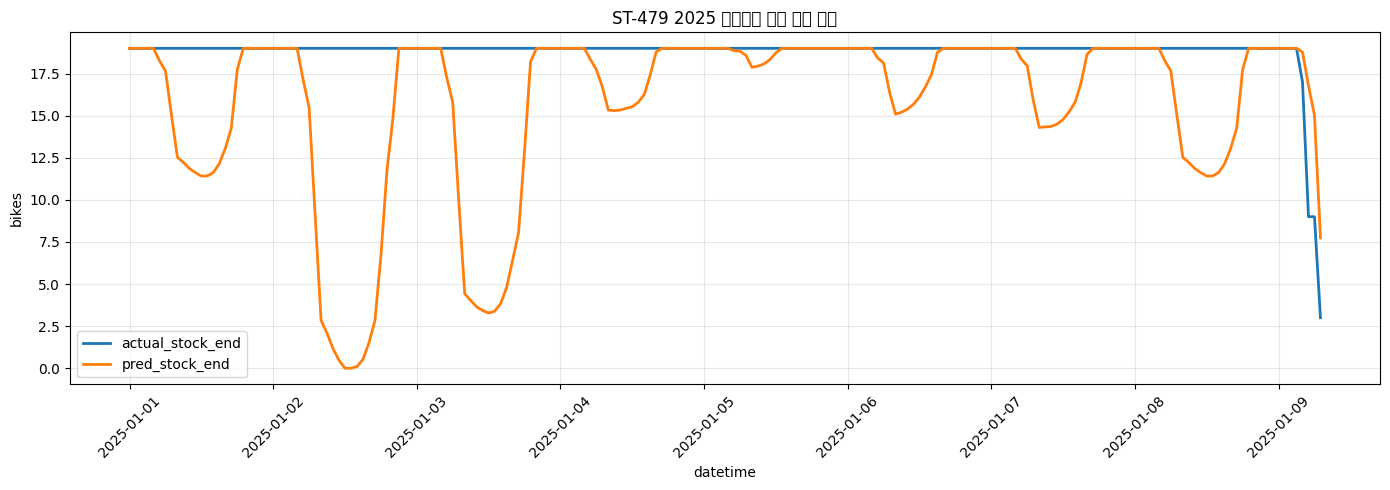

In [23]:
plot_station_id = 'ST-479'
plot_df = test_pred_stock[test_pred_stock['대여소_ID'] == plot_station_id].head(200).copy()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(plot_df['event_datetime'], plot_df['actual_stock_end'], label='actual_stock_end', linewidth=2)
ax.plot(plot_df['event_datetime'], plot_df['pred_stock_end'], label='pred_stock_end', linewidth=2)
ax.set_title(f'{plot_station_id} 2025 시간대별 잔여 대수 예측')
ax.set_xlabel('datetime')
ax.set_ylabel('bikes')
ax.legend()
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 해석

이 노트북의 결과는 다음처럼 해석해야 합니다.

- 이 모델은 `실제 관측 재고`가 아니라 `proxy 재고`를 예측합니다.
- 따라서 절대적인 재고 수치보다 `시간대 패턴`, `스테이션 간 상대 비교`, `부족 가능 시간대 탐지`에 더 적합합니다.
- 운영에 바로 쓰려면 실제 재배치 로그, 실재고 로그, 혹은 최소한 일별 시작 재고 관측치가 추가로 필요합니다.

현재 조건에서 이 설계가 가장 좋은 이유는 다음과 같습니다.

- lag를 쓰지 않으면서도 재고 문제를 구조적으로 다룰 수 있습니다.
- 누수가 발생하기 쉬운 `동시간대 결과값`을 입력에서 제거했습니다.
- 공선성이 높은 파생 변수들을 넣지 않았습니다.
- `유입/유출 예측 -> 재고 시뮬레이션` 구조라서 설명 가능성이 높습니다.
